In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler



In [2]:
df= pd.read_csv('thyroid_dataset.csv')

In [3]:
df.head()
df.info()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   int64  
 2   on_thyroxine               6916 non-null   int64  
 3   query_on_thyroxine         6916 non-null   int64  
 4   on_antithyroid_medication  6916 non-null   int64  
 5   sick                       6916 non-null   int64  
 6   pregnant                   6916 non-null   int64  
 7   thyroid_surgery            6916 non-null   int64  
 8   I131_treatment             6916 non-null   int64  
 9   query_hypothyroid          6916 non-null   int64  
 10  query_hyperthyroid         6916 non-null   int64  
 11  lithium                    6916 non-null   int64  
 12  goitre                     6916 non-null   int64  
 13  tumor                      6916 non-null   int64

(6916, 22)

In [4]:
X= df.drop("Outlier_label", axis=1)
y= df["Outlier_label"]

In [5]:
sc=StandardScaler()
x_scaled=sc.fit_transform(X)

### Using LOF

In [8]:
from sklearn.neighbors import LocalOutlierFactor

lof= LocalOutlierFactor()

labels=lof.fit_predict(x_scaled)


In [9]:
# Visulize 

# we can use dimensionality reduction by PCA

from sklearn.decomposition import PCA
pca= PCA(n_components=2)
x_pca= pca.fit_transform(x_scaled)




Text(0, 0.5, 'PCA-2')

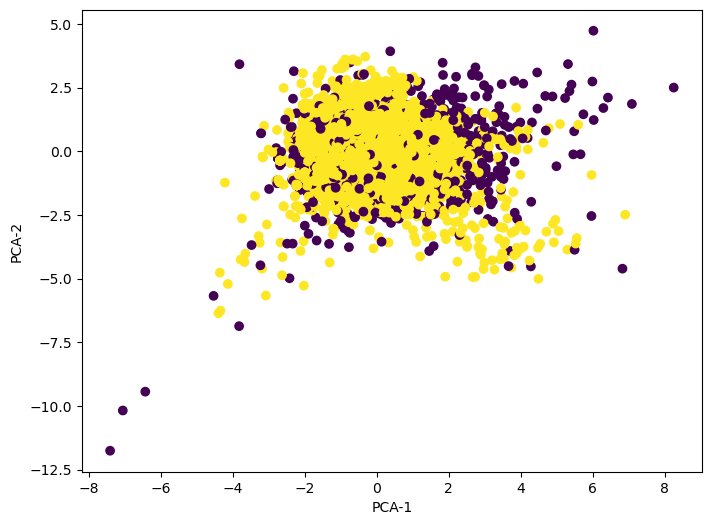

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")



In [11]:
import numpy as np

n_outliers=np.sum(labels==-1)

normal_points=np.sum(labels==1)
print(f"No of outliers :{n_outliers}")
print(f"No of Normal points {normal_points}")

No of outliers :883
No of Normal points 6033


No of outliers :249
No of Normal points 6667


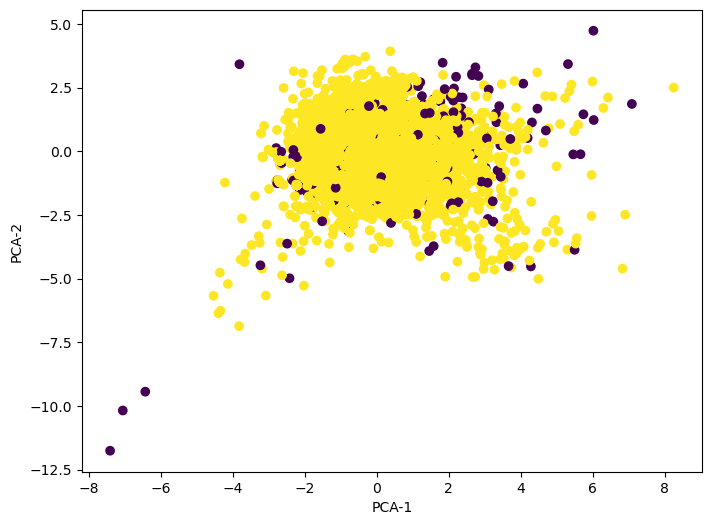

In [13]:
from sklearn.neighbors import LocalOutlierFactor

lof= LocalOutlierFactor( contamination=0.036)
labels=lof.fit_predict(x_scaled)

# Visulize 

# we can use dimensionality reduction by PCA



plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")




n_outliers=np.sum(labels==-1)

normal_points=np.sum(labels==1)
print(f"No of outliers :{n_outliers}")
print(f"No of Normal points {normal_points}")
